In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
from scipy import stats

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [2]:
specifiedpath = "D:\\"
filepath = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_bothresponders_Full.xlsx"

df = pd.read_excel(filepath)


In [ ]:
acr = df[df['responder'] == 'ACR'].set_index('MBON')
chrimson = df[df['responder'] == 'Chrimson2'].set_index('MBON')

mbons = acr.index.intersection(chrimson.index)
acr = acr.loc[mbons]
chrimson = chrimson.loc[mbons]

pref_acr = (acr['PI_Hg_OSAR'].abs() + acr['Light Attraction Index_Hg_OSAR'].abs()) / 2
pref_chr = (chrimson['PI_Hg_OSAR'].abs() + chrimson['Light Attraction Index_Hg_OSAR'].abs()) / 2

loco_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs() + acr['Bout Number Index_Hg_OSAR'].abs() + acr['Bout Duration ratio_Hg_OSAR'].abs()) / 3
loco_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs() + chrimson['Bout Number Index_Hg_OSAR'].abs() + chrimson['Bout Duration ratio_Hg_OSAR'].abs()) / 3

comb_acr = (pref_acr + loco_acr) / 2
comb_chr = (pref_chr + loco_chr) / 2

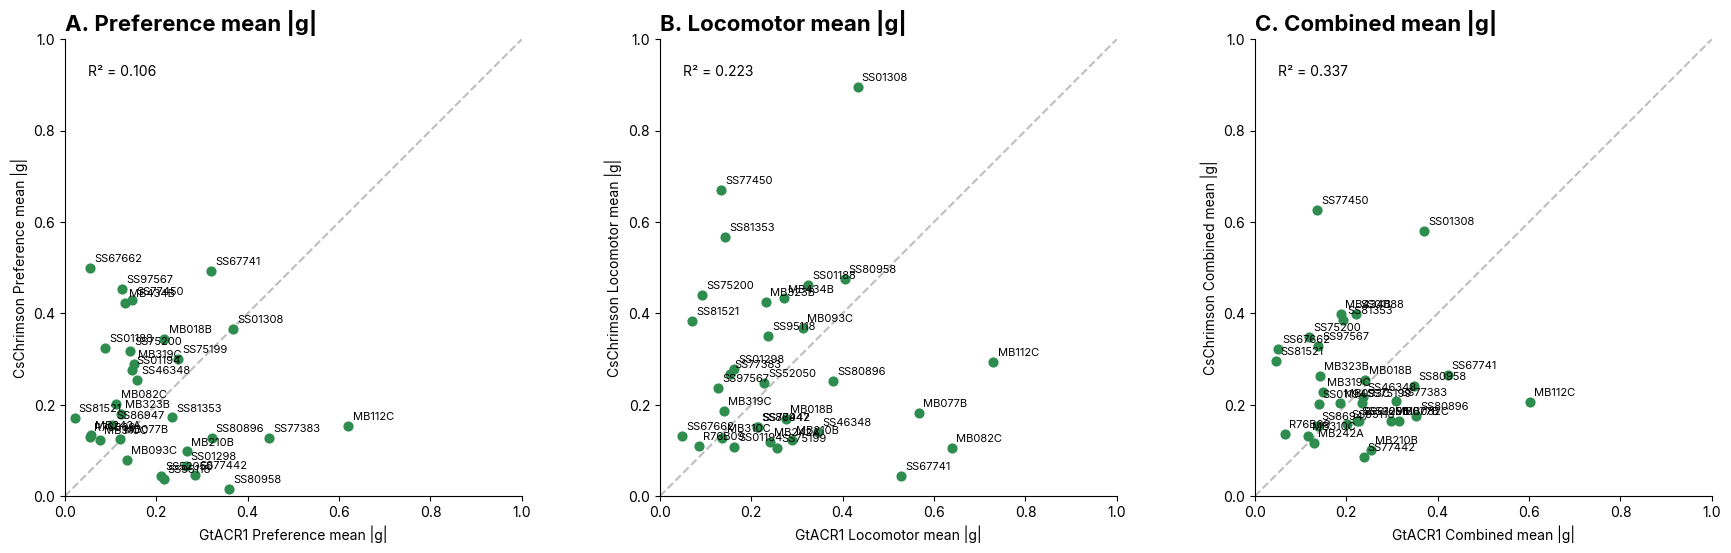

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (pref_acr, pref_chr, 'Preference mean |g|'),
    (loco_acr, loco_chr, 'Locomotor mean |g|'),
    (comb_acr, comb_chr, 'Combined mean |g|'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B', 'C']):
    ax.scatter(x, y, s=40, color='#2D8C4E', zorder=3)

    for mbon in mbons:
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel(f'GtACR1 {title}', fontsize=10)
    ax.set_ylabel(f'CsChrimson {title}', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\phenomics" + date +".svg", bbox_inches='tight')
plt.show()

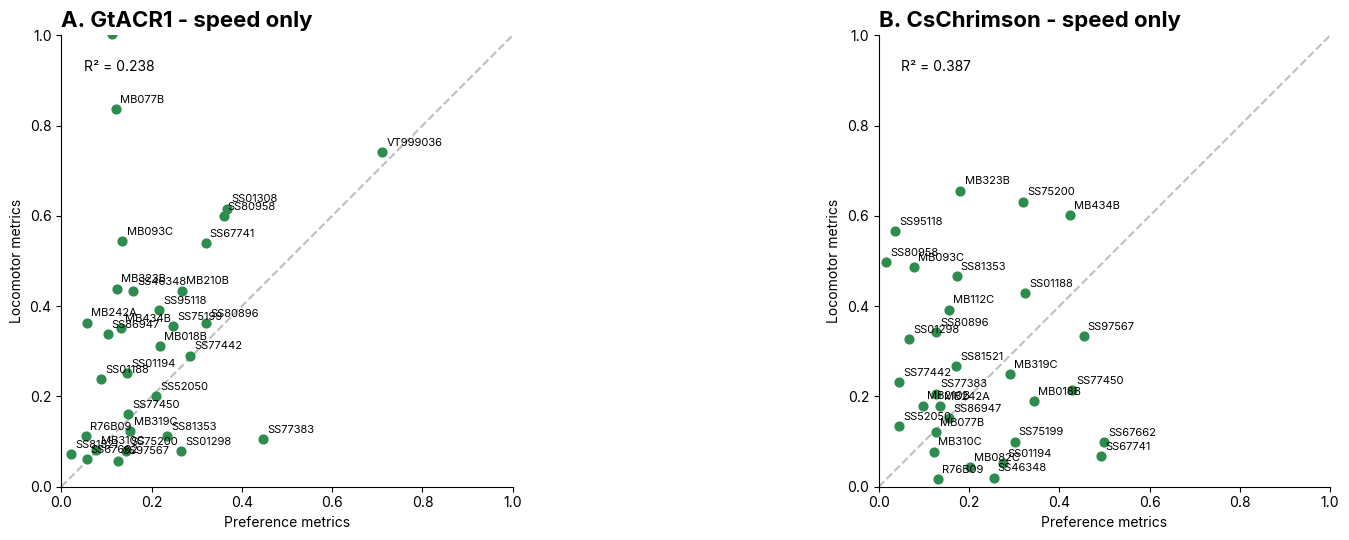

In [19]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (pref_acr, acr['Log2 Bout Speed ratio_Hg_OSAR'].abs(), 'GtACR1 - speed only'),
    (pref_chr, chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs(), 'CsChrimson - speed only')
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x, y, s=40, color='#2D8C4E', zorder=3)

    for mbon in mbons:
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel(f'Preference metrics', fontsize=10)
    ax.set_ylabel(f'Locomotor metrics', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\phenomics" + date +".svg", bbox_inches='tight')
plt.show()

In [17]:
weighted_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs())*0.5 + (acr['Bout Number Index_Hg_OSAR'].abs())*0.25 + (acr['Bout Duration ratio_Hg_OSAR'].abs())*0.25
weighted_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs())*0.5 + (chrimson['Bout Number Index_Hg_OSAR'].abs())*0.25 + (chrimson['Bout Duration ratio_Hg_OSAR'].abs())*0.25

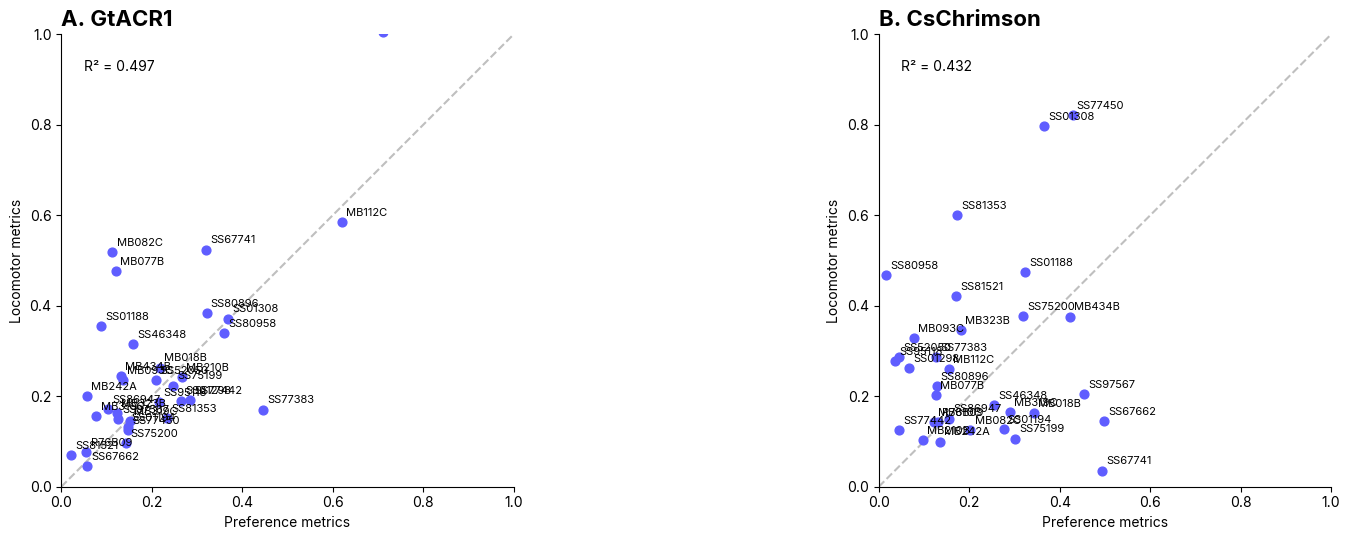

In [26]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (pref_acr,loco_acr, 'GtACR1'),
    (pref_chr, loco_chr, 'CsChrimson')
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x, y, s=40, color="#5F5DFF", zorder=3)

    for mbon in mbons:
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel(f'Preference metrics', fontsize=10)
    ax.set_ylabel(f'Locomotor metrics', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\phenomics" + date +".svg", bbox_inches='tight')
plt.show()

In [10]:
df_total = pd.DataFrame()
df_total["Preference mean_ACR"] = pref_acr
df_total["Preference mean_Chrimson2"] = pref_chr
df_total["Locomotor mean_ACR"] = loco_acr
df_total["Locomotor mean_Chrimson2"] =loco_chr
df_total["Combined mean_ACR"] = comb_acr
df_total["Combined mean_Chrimson2"] = comb_chr

df_total.to_csv("combined_mean.csv")

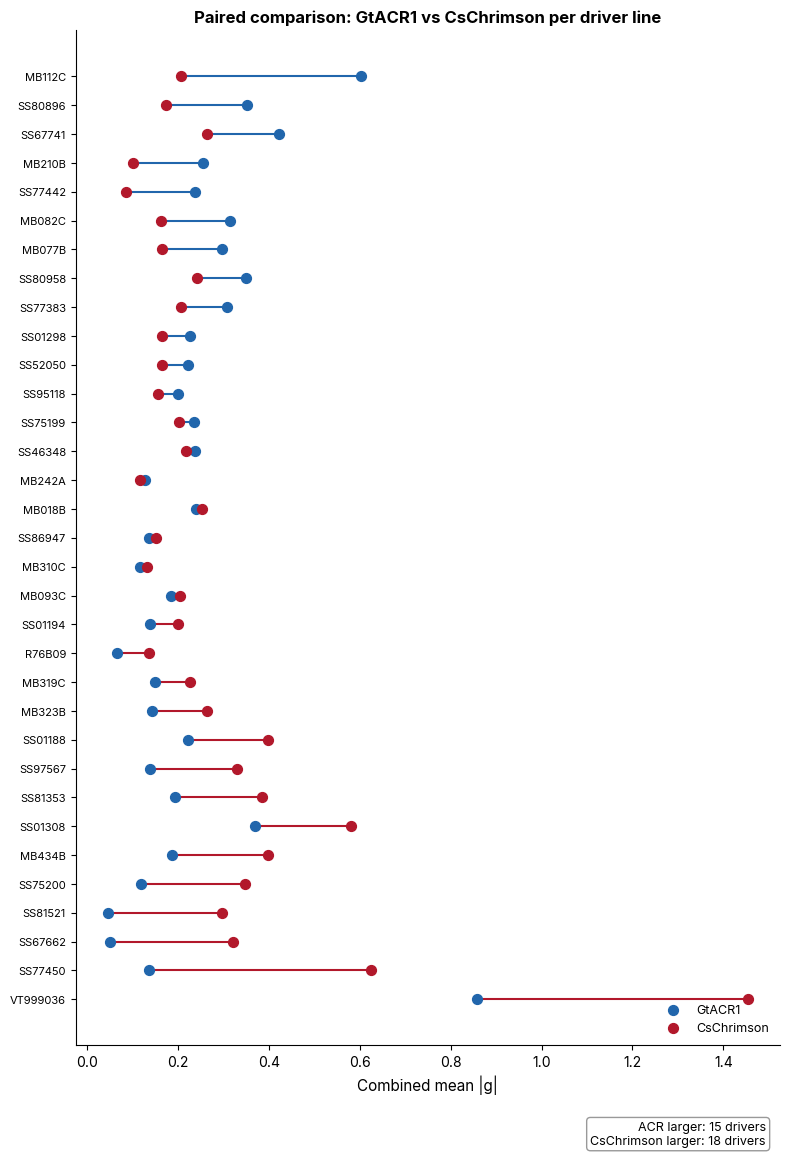

In [7]:
# Paired dot plot: GtACR1 vs CsChrimson Combined mean |g| per driver line
diff = comb_acr - comb_chr
sorted_mbons = diff.sort_values().index  # sort by difference (most CsChrimson-dominant at top)

fig, ax = plt.subplots(figsize=(8, max(6, len(sorted_mbons) * 0.35)))

for i, mbon in enumerate(sorted_mbons):
    acr_val = comb_acr[mbon]
    chr_val = comb_chr[mbon]
    color = '#2166AC' if acr_val > chr_val else '#B2182B'  # blue if ACR larger, red if CsChrimson larger
    ax.plot([acr_val, chr_val], [i, i], '-', color=color, linewidth=1.5, zorder=2)
    ax.scatter(acr_val, i, color='#2166AC', s=50, zorder=3, label='GtACR1' if i == 0 else '')
    ax.scatter(chr_val, i, color='#B2182B', s=50, zorder=3, label='CsChrimson' if i == 0 else '')

ax.set_yticks(range(len(sorted_mbons)))
ax.set_yticklabels(sorted_mbons, fontsize=8)
ax.set_xlabel('Combined mean |g|', fontsize=11)
ax.set_title('Paired comparison: GtACR1 vs CsChrimson per driver line', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(loc='lower right', fontsize=9, frameon=False)

# Summary counts
n_acr = (diff > 0).sum()
n_chr = (diff < 0).sum()
ax.text(0.98, -0.1, f'ACR larger: {n_acr} drivers\nCsChrimson larger: {n_chr} drivers',
        transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()